In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import torch
import clip
from PIL import Image
from PIL import ImageOps
import cv2
import pytesseract

import numpy as np
import pandas as pd
import copy
import os
import glob

import datetime as dt
import time
from timethis import timethis
import subprocess
from common_params import parent_directory_images, parent_directory_url_csvs
from preprocess_data_fns import create_image_files_df, get_predicted_categories_clip, categorize_and_plot, categories


In [60]:
def preprocess_image_for_banner_text(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    return thresh


def banner_text_box(image_path, preprocessing_fn, plot=False, margin=25):

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image_height = image.shape[0]

    # Apply thresholding to enhance text visibility
    image_processed = preprocessing_fn(image)

    # Detect text regions using Tesseract
    custom_config = r'--oem 3 --psm 3'  # OCR engine mode and page segmentation mode
    data = pytesseract.image_to_data(image_processed, config=custom_config, output_type=pytesseract.Output.DICT)

    # Draw bounding boxes around detected text
    data['is_banner']=[0] * len(data['text'])
    data['top_bottom']=[None] * len(data['text'])
    for i in range(len(data['text'])):
        if int(data['conf'][i]) > 50:  # Confidence threshold
            x, y, w, h = data['left'][i], data['top'][i], data['width'][i], data['height'][i]
            height_pct = int(100*y/image_height)
            depth_pct = int(100*h/image_height)
            is_banner = all([
                depth_pct <= 20,
                (height_pct <= margin or height_pct >= (100-margin))
            ])
            if is_banner:
                data['is_banner'][i] = 1 #
                data['top_bottom'][i] = 'top' if height_pct <= margin else 'bottom' if height_pct >= (100-margin) else None
                cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)

    if plot:
        plt.imshow(image)
        plt.axis("off")  # Hide axis
        plt.show()

    return data

In [3]:
## let's see if we get a higher probability of 'car exterior' after cropping

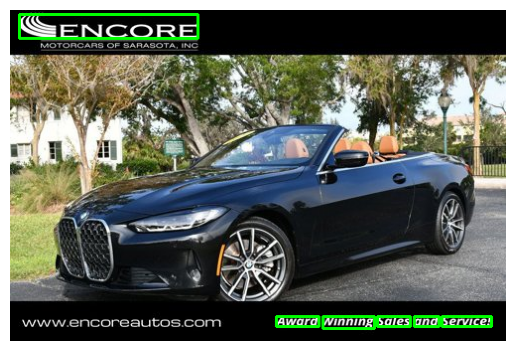

In [61]:
image_path='/Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-bmw/model-4-series/vehicle_id-735462554/279fbaf57ca9488997e5b1a4189e6596.jpg'

data = banner_text_box(image_path, preprocess_image_for_banner_text, plot=True)

In [5]:
text_banner_data = banner_text_box(image_path, preprocess_image_for_banner_text, plot=False)
text_banner_data.keys()

# text_banner_data = list(filter(
#     lambda x: x['is_banner']==1,
#     text_banner_data
# ))
# print(len(text_banner_data))
# text_banner_data[0]


dict_keys(['level', 'page_num', 'block_num', 'par_num', 'line_num', 'word_num', 'left', 'top', 'width', 'height', 'conf', 'text', 'is_banner', 'top_bottom'])

In [6]:
# banner_indices = [i for i,x in enumerate(text_banner_data['is_banner']) if x==1]
# banner_indices
#
# text_banner_data2 = {}
# for k,v in text_banner_data.items():
#     text_banner_data2[k] = [x for i,x in enumerate(v) if i in banner_indices]
#
# text_banner_data2['text']

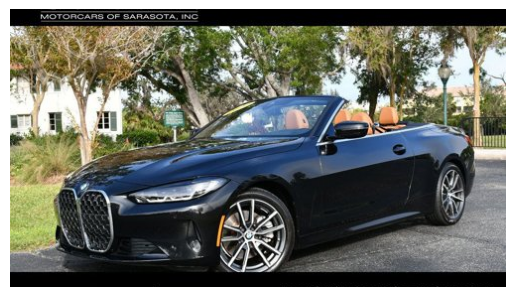

In [33]:
banner_indices_top = [i for i,x in enumerate(text_banner_data['top_bottom']) if x=='top']
banner_indices_top

text_banner_top = {}
for k,v in text_banner_data.items():
    text_banner_top[k] = [x for i,x in enumerate(v) if i in banner_indices_top]
    

banner_indices_bottom = [i for i,x in enumerate(text_banner_data['top_bottom']) if x=='bottom']
banner_indices_bottom

text_banner_bottom = {}
for k,v in text_banner_data.items():
    text_banner_bottom[k] = [x for i,x in enumerate(v) if i in banner_indices_bottom]

banner_indices_bottom

argmin_top= np.argmax(text_banner_top['top'])
top_slice = text_banner_top['top'][argmin_top] + text_banner_top['height'][argmin_top]
top_slice

bottom_slice = np.max(text_banner_bottom['top'])
bottom_slice

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


cropped_image = image[top_slice: bottom_slice,:,:]
# plt.figure(figsize=(10,10))
plt.imshow(cropped_image)
plt.axis("off")  
plt.show()


In [12]:
# cv2.imwrite('cropped_image.jpg', cropped_image)
cv2.imwrite('cropped_image.jpg', cv2.cvtColor(cropped_image, cv2.COLOR_RGB2BGR))


True

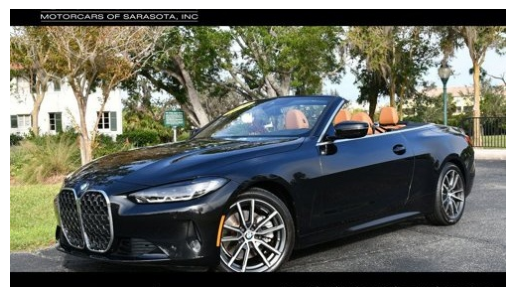

In [13]:
data = banner_text_box('cropped_image.jpg', preprocess_image_for_banner_text, plot=True)

In [14]:
## learn if predicted prob of exterior increased

probs_before = get_predicted_categories_clip(
    image_path= image_path,
    categories=categories
)['car exterior']


probs_after = get_predicted_categories_clip(
    image_path= 'cropped_image.jpg',
    categories=categories
)['car exterior']

probs_after, probs_before, probs_after-probs_before

(0.83413076, 0.37753057, 0.4566002)

In [29]:
value = 0.75
formatted_percentage = f"abc {value:.2%}"
print(formatted_percentage)

message = f"prob of car exterior went from {probs_before:.2%} to {probs_after:.2%} "
print(message)
# message = f"prob of car exterior went from {probs_before:.2%)}"
# print(message)

abc 75.00%
prob of car exterior went from 37.75%


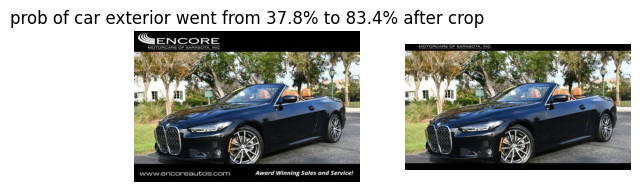

In [32]:
plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
message = f"prob of car exterior went from {probs_before:.1%} to {probs_after:.1%} after crop"

plt.imshow(image)
plt.axis("off")
plt.title(message)

# Show second image
plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
plt.imshow(cropped_image)
plt.axis("off")
plt.show()

In [34]:
image.shape

(334, 500, 3)

In [81]:
def crop_out_text(image_path:str,new_path:str=None,plot:bool=False,margin:int=20) -> dict:
    
    text_banner_data = banner_text_box(image_path, preprocess_image_for_banner_text, plot=False, margin=margin)
    
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_height = image.shape[0]
    
    banner_indices_top = [i for i,x in enumerate(text_banner_data['top_bottom']) if x=='top']
    if banner_indices_top:

        text_banner_top = {}
        for k,v in text_banner_data.items():
            text_banner_top[k] = [x for i,x in enumerate(v) if i in banner_indices_top]
        
        argmin_top= np.argmax(text_banner_top['top'])
        top_slice = text_banner_top['top'][argmin_top] + text_banner_top['height'][argmin_top]
    else:
        top_slice=0
        
    banner_indices_bottom = [i for i,x in enumerate(text_banner_data['top_bottom']) if x=='bottom']
    if banner_indices_bottom:
        
        text_banner_bottom = {}
        for k,v in text_banner_data.items():
            text_banner_bottom[k] = [x for i,x in enumerate(v) if i in banner_indices_bottom]
        
        bottom_slice = np.min(text_banner_bottom['top'])
    else:
        bottom_slice = image_height

    no_text_banner = all([
        len(banner_indices_top)==0,
        len(banner_indices_bottom)==0,
    ])
    if no_text_banner:
        print('no_text_banner')
        cropped_image = probs_before= probs_after = probs_diff = None

    
    else:
        cropped_image = image[top_slice: bottom_slice,:,:]
        cv2.imwrite('cropped_image.jpg', cv2.cvtColor(cropped_image, cv2.COLOR_RGB2BGR))
    
        probs_before = get_predicted_categories_clip(
            image_path= image_path,
            categories=categories
        )['car exterior']
        
        
        probs_after = get_predicted_categories_clip(
            image_path= 'cropped_image.jpg',
            categories=categories
        )['car exterior']

        probs_diff=probs_after-probs_before
        
        if plot:    
            plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
            message = f"prob of car exterior went from {probs_before:.1%} to {probs_after:.1%} after crop"
            
            plt.imshow(image)
            plt.axis("off")
            plt.title(message)
            
            # Show second image
            plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
            plt.imshow(cropped_image)
            plt.axis("off")
            plt.show()    

    return {
        'cropped_image':cropped_image,
        'probs_before':probs_before,
        'probs_after':probs_after,
        'probs_diff': probs_diff
    }

    

In [82]:
!rm 'cropped_image.jpg'

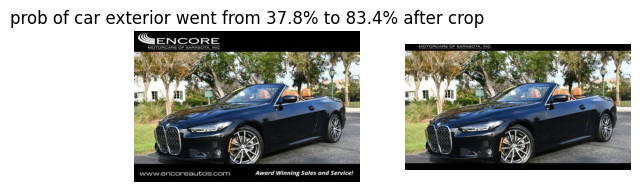

In [83]:
image_path='/Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-bmw/model-4-series/vehicle_id-735462554/279fbaf57ca9488997e5b1a4189e6596.jpg'
cropping_result =  crop_out_text(image_path, plot=True)

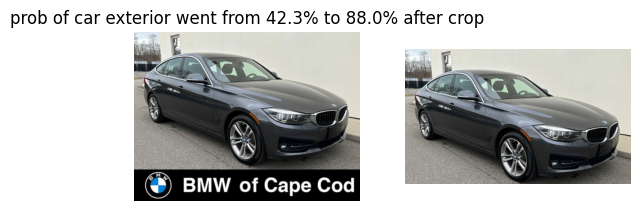

In [84]:
## example w bottom text only
image_path='/Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-bmw/model-3-series/vehicle_id-738165021/a364806167b74b54be97fbe9d7511b4a.jpg'
cropping_result =  crop_out_text(image_path, plot=True)

In [85]:
## recursive example - should have no effect 
image_path='cropped_image.jpg'
cropping_result =  crop_out_text(image_path, plot=True)
cropping_result

no_text_banner


{'cropped_image': None,
 'probs_before': None,
 'probs_after': None,
 'probs_diff': None}

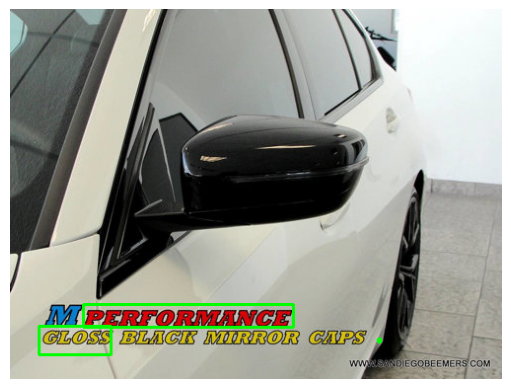

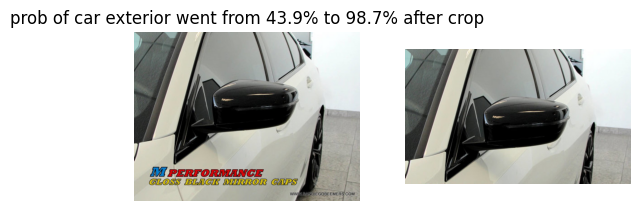

In [86]:
# example w multiple rows of text
image_path='/Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-bmw/model-3-series/vehicle_id-728101019/65b9c8cb3af64c7581442421e0420839.jpg'
data = banner_text_box(image_path, preprocess_image_for_banner_text, plot=True, margin=25)
cropping_result =  crop_out_text(image_path, plot=True,margin=25)

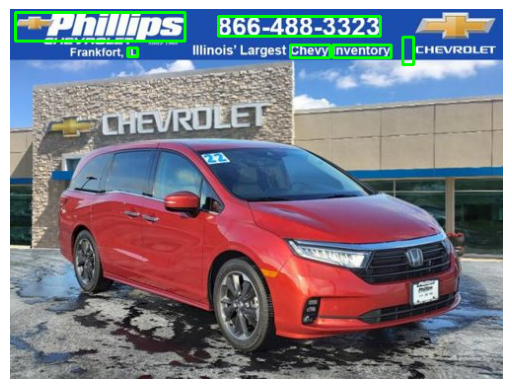

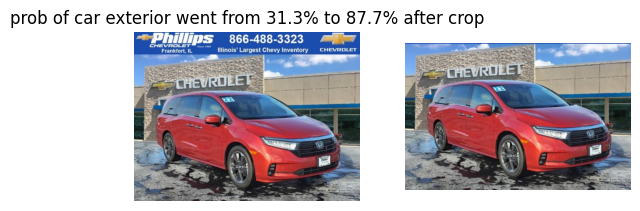

In [87]:
## top text example
image_path='/Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-honda/model-odyssey/vehicle_id-732088109/2e4256fdf3e147ea80197b1e3527c1e7.jpg'
data = banner_text_box(image_path, preprocess_image_for_banner_text, plot=True, margin=25)
cropping_result =  crop_out_text(image_path, plot=True,margin=25)